<span style="color:red; font-family:Helvetica Neue, Helvetica, Arial, sans-serif; font-size:2em;">An Exception was encountered at '<a href="#papermill-error-cell">In [10]</a>'.</span>

# OncoBridge-MMCAT v7 — 4-Modality Pan-Cancer Classifier
## Clean rebuild. Evidence-based. No overengineering.

### What we know works (from all previous versions):
| Setting | Value | Why |
|---------|-------|-----|
| embed_dim | 384 | v3 got 91.94% with this — v5's 512 → 85M params → overfit |
| encoder layers | 6 | v3 proven |
| cross-attn layers | 4 | v3 proven |
| ff_dim | 1536 | v3 proven |
| OneCycleLR | ✅ | CosineRestarts in v5 → 83.95%. OneCycleLR wins. |
| CE + class weights | ✅ | v3 CE beat v4 focal. Gamma hurts with class weights combined. |
| Mixup prob | 0.5 | v3 proven — do NOT reduce when model is large |
| batch=64, accum=8 | 512 eff. | Proper GPU utilization |

### New in v7 (biologically correct):
- **Mutation: NO scaling** — it's binary (0/1). StandardScaler turns wildtype into negative floats. That's wrong.
- **Methylation: NO scaling** — beta values are already bounded [0,1]. StandardScaler distorts this.  
- **CNV: MaxAbsScaler** — preserves 0 (normal copy number), just scales -2/+2 to -1/+1.
- **mRNA: StandardScaler** — continuous log-expression, this is correct.
- **Gene importance gate init=1.5** — sigmoid(1.5)=0.82 (mostly open at start, learns to close noisy genes)
- **4th modality: DNA Methylation** — epigenetic silencing signal, very predictive for cancer type

### Gene count question (honest answer):
There's no magic number. We use variance-based auto-k: keep enough genes to explain 85% of
total training variance. This is principled (not arbitrary), fast (just cumsum), and reproducible.
For methylation after probe→gene mapping, gene-level beta values have much lower variance
than mRNA — so auto-k typically picks 4000-6000 genes there.


In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.utils.checkpoint import checkpoint as grad_checkpoint
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler, MaxAbsScaler
from sklearn.metrics import (
    classification_report, accuracy_score, f1_score, matthews_corrcoef, confusion_matrix
)
from sklearn.utils.class_weight import compute_class_weight
from sklearn.feature_selection import VarianceThreshold
import copy, time, warnings
warnings.filterwarnings('ignore')

# ══════════════════════════════════════════════════════════════════════════
#  CENTRAL CONFIG — only change things here
# ══════════════════════════════════════════════════════════════════════════
CONFIG = {
    # ── Data paths ────────────────────────────────────────────────────────
    'mrna_path'  : '/mnt/f/main datasets/mrna_final.parquet',
    'cnv_path'   : '/mnt/f/main datasets/cnv_final.parquet',
    'mut_path'   : '/mnt/f/main datasets/mut_final.parquet',
    'meth_path'  : '/mnt/f/main datasets/meth_final.parquet',
    'label_path' : '/mnt/f/main datasets/labels_final.parquet',

    # ── Gene selection ────────────────────────────────────────────────────
    # AUTO-K by variance coverage (recommended):
    # Keeps the minimum number of genes that explain X% of total training variance.
    # This is principled — not arbitrary. Typically selects:
    #   mRNA:  ~7000-9000 genes (high variance, rich signal)
    #   CNV:   ~2000-3500 genes (low variance, segment-correlated)
    #   Mut:   ~1500-2500 genes (very sparse, low variance)
    #   Meth:  ~4000-6000 genes (moderate variance after probe averaging)
    # Hard caps prevent selecting too many and causing OOM or overfitting.
    'auto_k_coverage': 0.88,   # explain 88% of training variance per modality

    # Hard caps (never exceed these regardless of coverage):
    'mrna_max_k' : 9000,
    'cnv_max_k'  : 3500,
    'mut_max_k'  : 2500,
    'meth_max_k' : 6000,
    'active_modalities': ['mrna', 'cnv'],          # ← ablation control knob


    # ── Architecture (v3 proven values — do NOT change without reason) ────
    'embed_dim'         : 384,
    'num_heads'         : 8,
    'num_encoder_layers': 6,     # per-modality encoder transformer layers
    'num_cross_layers'  : 4,     # cross-modal attention layers
    'cnn_kernel'        : 16,
    'cnn_stride'        : 16,
    'ff_dim'            : 1536,
    'dropout'           : 0.20,

    # Gene importance gate init (reviewer advice: 1.5 → sigmoid=0.82, mostly open)
    # Model starts with gates ~82% open, learns to fully close on noisy genes
    'gate_init'         : 1.5,

    # ── Training ──────────────────────────────────────────────────────────
    'epochs'     : 140,
    'batch_size' : 64,
    'grad_accum' : 8,        # effective batch = 512
    'lr'         : 2e-4,
    'weight_decay': 3e-4,
    'patience'   : 18,
    'label_smoothing': 0.05,
    'clip_grad'  : 1.0,
    'warmup_frac': 0.15,     # 15% of total steps for LR warmup in OneCycleLR
    'checkpoint' : 'B2_mrna_cnv.pt',
    'num_workers': 4,
    'use_amp'    : True,
    'use_grad_ckpt': True,

    # ── Loss: CE + class weights (v3 beat focal here, stay with CE) ───────
    'max_class_weight': 8.0,  # cap weight for ultra-rare classes

    # ── Mixup (keep at 0.5 — v3 proven. DO NOT reduce when model is large) ─
    'use_mixup'  : True,
    'mixup_prob' : 0.50,
    'mixup_alpha': 0.2,

    # ── Class filter ──────────────────────────────────────────────────────
    'balanced_classes_only': True,  # False = use all classes
    'min_samples_per_class': 100,

    # ── Split ─────────────────────────────────────────────────────────────
    'use_test_set': True,    # True → 70/15/15 | False → 80/20
    'seed'        : 42,
}

# ── Hardware setup ────────────────────────────────────────────────────────
torch.manual_seed(CONFIG['seed'])
np.random.seed(CONFIG['seed'])
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
N_GPUS = torch.cuda.device_count() if torch.cuda.is_available() else 0

if torch.cuda.is_available():
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32       = True
    torch.backends.cudnn.benchmark        = True
    for i in range(N_GPUS):
        gb = torch.cuda.get_device_properties(i).total_memory / 1e9
        print(f'  GPU {i}: {torch.cuda.get_device_name(i)} — {gb:.1f} GB')

print(f'Primary device: {DEVICE}')
print(f'DataParallel: {N_GPUS > 1} ({N_GPUS} GPUs)')
print(f'Effective batch: {CONFIG["batch_size"]} × {CONFIG["grad_accum"]} = {CONFIG["batch_size"]*CONFIG["grad_accum"]}')
print(f'Target: >94% accuracy (beat T-GEM 94.92%)')


  GPU 0: NVIDIA RTX 4000 Ada Generation — 21.5 GB
Primary device: cuda
DataParallel: False (1 GPUs)
Effective batch: 64 × 8 = 512
Target: >94% accuracy (beat T-GEM 94.92%)


In [2]:
# ══════════════════════════════════════════════════════════════════════════
#  DATA LOADING — memory-efficient
#  All 4 parquets are loaded here. Parquet is columnar and compressed,
#  so even the methylation file (13GB raw → ~1-2GB parquet) loads fine.
#  If methylation parquet is still large, pd.read_parquet with columns= 
#  would let you load subsets, but for our pipeline full load is needed.
# ══════════════════════════════════════════════════════════════════════════

print('Loading 4 modalities from parquet...')
t0 = time.time()

mrna_df  = pd.read_parquet(CONFIG['mrna_path'])
cnv_df   = pd.read_parquet(CONFIG['cnv_path'])
mut_df   = pd.read_parquet(CONFIG['mut_path'])
meth_df  = pd.read_parquet(CONFIG['meth_path'])
label_df = pd.read_parquet(CONFIG['label_path'])

print(f'  mRNA:        {mrna_df.shape} | RAM: {mrna_df.memory_usage(deep=True).sum()/1e9:.2f} GB')
print(f'  CNV:         {cnv_df.shape}  | RAM: {cnv_df.memory_usage(deep=True).sum()/1e9:.2f} GB')
print(f'  Mutation:    {mut_df.shape}  | RAM: {mut_df.memory_usage(deep=True).sum()/1e9:.2f} GB')
print(f'  Methylation: {meth_df.shape} | RAM: {meth_df.memory_usage(deep=True).sum()/1e9:.2f} GB')
print(f'  Labels:      {label_df.shape}')
print(f'  Loaded in {time.time()-t0:.1f}s')

# ── Encode labels ─────────────────────────────────────────────────────────
le = LabelEncoder()
y  = le.fit_transform(label_df['_primary_disease'])
CONFIG['num_classes'] = len(le.classes_)

# Store raw arrays (float32 for mRNA/meth, keep int8 for CNV/mut)
X = {
    'mrna': mrna_df.values.astype(np.float32),
    'cnv' : cnv_df.values.astype(np.float32),   # will use MaxAbsScaler
    'mut' : mut_df.values.astype(np.float32),   # will NOT scale (binary)
    'meth': meth_df.values.astype(np.float32),  # will NOT scale (beta values)
}
del mrna_df, cnv_df, mut_df, meth_df
import gc; gc.collect()

print(f'\nClasses: {CONFIG["num_classes"]}')
print('Class distribution:')
for i, cls in enumerate(le.classes_):
    n = int(np.sum(y == i))
    bar = '█' * max(1, n // 25)
    print(f'  {i:2d}. {cls:<45} n={n:4d}  {bar}')


Loading 4 modalities from parquet...


  mRNA:        (7912, 15816) | RAM: 0.50 GB


  CNV:         (7912, 15816)  | RAM: 0.13 GB


  Mutation:    (7912, 15816)  | RAM: 0.13 GB


  Methylation: (7912, 15816) | RAM: 0.50 GB
  Labels:      (7912, 1)
  Loaded in 11.2s



Classes: 32
Class distribution:
   0. adrenocortical cancer                         n=  76  ███
   1. bladder urothelial carcinoma                  n= 402  ████████████████
   2. brain lower grade glioma                      n= 506  ████████████████████
   3. breast invasive carcinoma                     n= 646  █████████████████████████
   4. cervical & endocervical cancer                n= 275  ███████████
   5. cholangiocarcinoma                            n=  36  █
   6. colon adenocarcinoma                          n= 273  ██████████
   7. diffuse large b-cell lymphoma                 n=  37  █
   8. esophageal carcinoma                          n= 181  ███████
   9. glioblastoma multiforme                       n=  47  █
  10. head & neck squamous cell carcinoma           n= 488  ███████████████████
  11. kidney chromophobe                            n=  65  ██
  12. kidney clear cell carcinoma                   n= 255  ██████████
  13. kidney papillary cell carcinoma           

In [3]:
# ── Optional: drop classes with too few samples ──────────────────────────
if CONFIG['balanced_classes_only']:
    min_n   = CONFIG['min_samples_per_class']
    counts  = np.bincount(y)
    keep    = np.where(counts >= min_n)[0]
    dropped = [le.classes_[i] for i in range(len(le.classes_)) if i not in keep]
    mask    = np.isin(y, keep)
    for m in X: X[m] = X[m][mask]
    le_new  = LabelEncoder()
    y       = le_new.fit_transform(y[mask])
    le.classes_ = le.classes_[keep]
    CONFIG['num_classes'] = len(le.classes_)
    print(f'Kept {CONFIG["num_classes"]} classes (>={min_n} samples). Dropped: {dropped}')
else:
    print(f'Using ALL {CONFIG["num_classes"]} classes')

print(f'Total samples: {len(y)}')

# ── Train / Val / Test split ──────────────────────────────────────────────
idx = np.arange(len(y))
if CONFIG['use_test_set']:
    tr_idx, tmp = train_test_split(idx, test_size=0.30, stratify=y,
                                   random_state=CONFIG['seed'])
    vl_idx, te_idx = train_test_split(tmp, test_size=0.50, stratify=y[tmp],
                                      random_state=CONFIG['seed'])
    print(f'Split: Train={len(tr_idx)} | Val={len(vl_idx)} | Test={len(te_idx)}')
else:
    tr_idx, vl_idx = train_test_split(idx, test_size=0.20, stratify=y,
                                      random_state=CONFIG['seed'])
    te_idx = None
    print(f'Split: Train={len(tr_idx)} | Val={len(vl_idx)}')


Kept 22 classes (>=100 samples). Dropped: ['adrenocortical cancer', 'cholangiocarcinoma', 'diffuse large b-cell lymphoma', 'glioblastoma multiforme', 'kidney chromophobe', 'mesothelioma', 'ovarian serous cystadenocarcinoma', 'rectum adenocarcinoma', 'uterine carcinosarcoma', 'uveal melanoma']
Total samples: 7341
Split: Train=5138 | Val=1101 | Test=1102


In [4]:
# ══════════════════════════════════════════════════════════════════════════
#  GENE SELECTION — Auto-k by variance coverage
#
#  How we decide the number of genes:
#  1. Compute variance of each gene on TRAINING DATA ONLY (no leakage).
#  2. Sort genes by variance descending.
#  3. Take cumulative sum of sorted variances.
#  4. Find k = first index where cumsum >= coverage * total_variance.
#  5. k tells us: "this many genes explain 88% of all variance in the data."
#
#  Why 88% and not 95% or 70%?
#  - Too high (>92%) → includes many noisy, low-variance genes → overfitting
#  - Too low (<80%) → loses real biological signal → underfitting
#  - 85-90% is the standard range in dimensionality reduction literature
#  - We use 88% as a balanced default, capped by modality-specific maxima
#
#  Why NOT Mutual Information (tried in v5):
#  - MI took 600 seconds per modality
#  - Mutation MAD was 0.000 everywhere after log1p (still sparse) → random selection
#  - Result was WORSE (83.95% vs 91.94%) despite 10-min computation
#  - Variance selection is fast, standard, and worked in v3 (91.94%)
#
#  Modality-specific normalization (BIOLOGICALLY CORRECT, new in v7):
#  - mRNA:  StandardScaler → continuous log-expression, this is correct
#  - CNV:   MaxAbsScaler   → preserves 0 (normal diploid), scales -2/+2 to -1/+1
#  - Mut:   NO SCALING     → binary 0/1 data. StandardScaler would turn wildtype (0)
#                            into a negative float and mutated (1) into a large positive.
#                            That destroys the biological meaning entirely.
#  - Meth:  NO SCALING     → beta values are already bounded [0,1] and interpretable.
#                            StandardScaler would distort the bounded distribution.
# ══════════════════════════════════════════════════════════════════════════

MAX_K = {
    'mrna': CONFIG['mrna_max_k'],
    'cnv' : CONFIG['cnv_max_k'],
    'mut' : CONFIG['mut_max_k'],
    'meth': CONFIG['meth_max_k'],
}

SCALER_TYPE = {
    'mrna': 'standard',    # continuous log-expression
    'cnv' : 'maxabs',      # ordinal, preserve zero
    'mut' : 'none',        # binary 0/1 — do NOT scale
    'meth': 'none',        # beta values [0,1] — do NOT scale
}

def select_and_scale(X_full, y_train_idx, split_indices,
                     coverage, max_k, scaler_type, tag):
    """
    1. Variance-based auto-k gene selection (train-only, no leakage)
    2. Modality-appropriate normalization
    Returns: (X_tr, X_vl, X_te_or_None, k_selected)
    """
    X_tr_raw = X_full[split_indices[0]]
    X_vl_raw = X_full[split_indices[1]]
    X_te_raw = X_full[split_indices[2]] if split_indices[2] is not None else None

    # Step 1: Remove zero-variance genes
    vt = VarianceThreshold(threshold=0.0)
    vt.fit(X_tr_raw)
    variances = vt.variances_

    # Step 2: Auto-k by cumulative variance coverage
    sorted_var = np.sort(variances)[::-1]
    total_var  = sorted_var.sum()
    cumsum     = np.cumsum(sorted_var)
    auto_k     = int(np.searchsorted(cumsum, coverage * total_var)) + 1
    k          = min(auto_k, max_k)

    top_idx = np.argsort(variances)[::-1][:k]

    X_tr = X_tr_raw[:, top_idx]
    X_vl = X_vl_raw[:, top_idx]
    X_te = X_te_raw[:, top_idx] if X_te_raw is not None else None

    # Step 3: Normalisation
    if scaler_type == 'standard':
        sc = StandardScaler()
        X_tr = sc.fit_transform(X_tr).astype(np.float32)
        X_vl = sc.transform(X_vl).astype(np.float32)
        X_te = sc.transform(X_te).astype(np.float32) if X_te is not None else None
        scale_note = 'StandardScaler'

    elif scaler_type == 'maxabs':
        sc = MaxAbsScaler()
        X_tr = sc.fit_transform(X_tr).astype(np.float32)
        X_vl = sc.transform(X_vl).astype(np.float32)
        X_te = sc.transform(X_te).astype(np.float32) if X_te is not None else None
        scale_note = 'MaxAbsScaler (preserves 0)'

    else:  # 'none'
        X_tr = X_tr.astype(np.float32)
        X_vl = X_vl.astype(np.float32)
        X_te = X_te.astype(np.float32) if X_te is not None else None
        scale_note = 'NO SCALING (biologically correct for this modality)'

    var_min = float(variances[top_idx].min())
    var_max = float(variances[top_idx].max())
    print(f'  [{tag:4s}] auto-k={auto_k} → capped at {k} | '
          f'var range: {var_min:.4f}–{var_max:.4f} | {scale_note}')
    return X_tr, X_vl, X_te, k


print(f'=== Gene Selection (variance coverage={CONFIG["auto_k_coverage"]*100:.0f}%) ===')
splits = (tr_idx, vl_idx, te_idx)

Xp = {}   # processed: {mod: (X_tr, X_vl, X_te)}
gene_k = {}

for mod in CONFIG['active_modalities']:
    tr, vl, te, k = select_and_scale(
        X[mod], tr_idx, splits,
        coverage=CONFIG['auto_k_coverage'],
        max_k=MAX_K[mod],
        scaler_type=SCALER_TYPE[mod],
        tag=mod
    )
    Xp[mod]    = (tr, vl, te)
    gene_k[mod] = k
    CONFIG[f'num_{mod}_genes'] = k

print(f'\nSelected genes: {gene_k}')
print(f'Total features: {sum(gene_k.values()):,}')
del X; gc.collect()

# ── Class weights ─────────────────────────────────────────────────────────
cw  = compute_class_weight('balanced', classes=np.unique(y[tr_idx]), y=y[tr_idx])
cw  = np.clip(cw, None, CONFIG['max_class_weight'])
cw_tensor = torch.FloatTensor(cw).to(DEVICE)
print(f'\nClass weights: {cw.min():.3f} – {cw.max():.3f}')
print(f'Heaviest (rarest): {le.classes_[np.argmax(cw)]} (w={cw.max():.2f})')


=== Gene Selection (variance coverage=88%) ===


  [mrna] auto-k=8011 → capped at 8011 | var range: 1.4596–24.5800 | StandardScaler


  [cnv ] auto-k=13429 → capped at 3500 | var range: 0.3971–0.6839 | MaxAbsScaler (preserves 0)

Selected genes: {'mrna': 8011, 'cnv': 3500}
Total features: 11,511



Class weights: 0.517 – 2.814
Heaviest (rarest): thymoma (w=2.81)


In [5]:
class MultiOmicsDataset(Dataset):
    def __init__(self, data_dict, labels):
        # data_dict: {mod_name: np.array}
        self.data   = {m: torch.FloatTensor(v) for m, v in data_dict.items()}
        self.labels = torch.LongTensor(labels)
        self.mods   = list(data_dict.keys())

    def __len__(self): return len(self.labels)

    def __getitem__(self, i):
        return {m: self.data[m][i] for m in self.mods}, self.labels[i]


def make_loader(split_key, shuffle):
    ki      = {'tr': 0, 'vl': 1, 'te': 2}[split_key]
    idx     = {'tr': tr_idx, 'vl': vl_idx, 'te': te_idx}[split_key]

    data_dict = {}
    for mod in CONFIG['active_modalities']:
        arr = Xp[mod][ki]
        if arr is None: arr = Xp[mod][1]   # fallback val → test
        data_dict[mod] = arr

    ds = MultiOmicsDataset(data_dict, y[idx])
    nw = CONFIG['num_workers']
    return DataLoader(
        ds, batch_size=CONFIG['batch_size'], shuffle=shuffle,
        num_workers=nw, pin_memory=True,
        persistent_workers=(nw > 0),
        prefetch_factor=2 if nw > 0 else None,
        drop_last=shuffle,
    )

train_loader = make_loader('tr', shuffle=True)
val_loader   = make_loader('vl', shuffle=False)
test_loader  = make_loader('te', shuffle=False) if te_idx is not None else None
print(f'Train batches: {len(train_loader)} | Val batches: {len(val_loader)}')
print(f'Active modalities: {CONFIG["active_modalities"]}')

Train batches: 80 | Val batches: 18
Active modalities: ['mrna', 'cnv']


In [6]:
# ══════════════════════════════════════════════════════════════════════════
#  ARCHITECTURE — OncoBridge-MMCAT v7
#
#  Components and why each exists:
#
#  1. GeneImportanceLayer (T-GEM inspired):
#     T-GEM learns gene-specific Query/Key/Value weights — each gene has its
#     own Q/K/V projection. We approximate this with a simpler learnable
#     sigmoid gate per gene. The gate starts at sigmoid(1.5)=0.82 (mostly
#     open), and during training learns to amplify informative genes and
#     suppress noisy ones. This is a dynamic refinement on top of our static
#     variance-based selection. Cost: num_genes params per modality (tiny).
#
#  2. ModalityEncoder (CNN + Transformer):
#     - Linear(1 → E): projects each scalar gene value into embed space
#     - Conv1d (stride=16): compresses gene sequence into shorter token seq
#       (e.g. 8000 genes → 500 tokens). Without this, self-attention on 8000
#       tokens would be 64M attention elements per head — too slow.
#     - CLS token: learnable summary token for the modality (like BERT CLS)
#     - TransformerEncoder (6 layers): models gene-gene interactions within
#       one modality. Uses pre-norm (norm_first=True) for training stability.
#
#  3. CrossModalAttention4 (4-modality):
#     Each modality attends to the concatenated sequences of ALL other 3.
#     This captures cross-omics interactions:
#       - mRNA attends to CNV+Mut+Meth: "which genes are expressed AND
#         amplified AND hypomethylated?" (triple evidence for oncogenes)
#       - Meth attends to mRNA+CNV+Mut: "which silenced genes also have CNV
#         loss?" (tumor suppressor evidence)
#     4 cross-attention layers lets information propagate fully across modalities.
#
#  4. GatedFusion4 (4-way soft gating):
#     Learns per-sample, per-modality weights.
#     For brain cancer: methylation and mRNA may dominate.
#     For skin cancer: mutation burden dominates.
#     The gate learns this automatically from data.
#
#  5. Classifier: 5×E → 2E → E → num_classes
#     Input = [cls_mrna | cls_cnv | cls_mut | cls_meth | fused] = 5×384 = 1920
#     Kept deep enough to separate 31 classes but not so deep as to overfit.
# ══════════════════════════════════════════════════════════════════════════


class GeneImportanceLayer(nn.Module):
    """
    Per-gene learnable sigmoid gate. T-GEM inspired.
    init_val=1.5 → sigmoid(1.5)=0.818 (mostly open at start).
    Network learns to close gate on noisy/irrelevant genes.
    """
    def __init__(self, num_genes, init_val=1.5):
        super().__init__()
        self.logits = nn.Parameter(torch.full((num_genes,), init_val))

    def forward(self, x):
        # x: (B, G) — gene expression values
        # gate: (G,) — per-gene importance in (0, 1)
        return x * torch.sigmoid(self.logits)


class ModalityEncoder(nn.Module):
    """
    Single-modality encoder: GeneGate → Linear → CNN → CLS + TransformerEncoder
    Same design as v3 which achieved 91.94%. Proven architecture.
    """
    def __init__(self, num_genes, embed_dim, num_heads, num_layers,
                 cnn_kernel, cnn_stride, ff_dim, dropout,
                 gate_init=1.5, use_ckpt=False):
        super().__init__()
        self.use_ckpt = use_ckpt

        # T-GEM inspired gene importance gating
        self.gene_gate = GeneImportanceLayer(num_genes, init_val=gate_init)

        # Project each scalar gene value into embed_dim space
        # Each gene becomes a vector of size embed_dim
        self.input_proj = nn.Linear(1, embed_dim)

        # 1D CNN: compresses gene sequence to manageable token count
        # Without this: 8000 genes → 8000 tokens → O(64M) attention per head
        # With stride=16: 8000 genes → ~500 tokens → O(250K) attention per head
        self.cnn = nn.Sequential(
            nn.Conv1d(embed_dim, embed_dim,
                      kernel_size=cnn_kernel, stride=cnn_stride,
                      padding=cnn_kernel // 2),
            nn.GELU(),
            nn.BatchNorm1d(embed_dim),
        )

        # CLS token — global summary learnable vector for this modality
        self.cls_token = nn.Parameter(torch.randn(1, 1, embed_dim) * 0.02)

        # Positional embedding sized to compressed sequence length
        compressed = (num_genes + cnn_kernel // 2 * 2 - cnn_kernel) // cnn_stride + 1 + 1
        self.pos_emb = nn.Parameter(torch.randn(1, compressed, embed_dim) * 0.02)

        # Pre-norm TransformerEncoder (norm_first=True = more stable training)
        enc_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim, nhead=num_heads,
            dim_feedforward=ff_dim, dropout=dropout,
            batch_first=True, norm_first=True,
        )
        self.transformer = nn.TransformerEncoder(enc_layer, num_layers=num_layers)
        self.norm = nn.LayerNorm(embed_dim)

    def _tfm(self, x): return self.transformer(x)

    def forward(self, x):
        # x: (B, G)
        x = self.gene_gate(x)            # per-gene importance weighting
        x = x.unsqueeze(-1)              # (B, G, 1)
        x = self.input_proj(x)           # (B, G, E)
        x = x.transpose(1, 2)           # (B, E, G) for Conv1d
        x = self.cnn(x)                 # (B, E, G//stride)
        x = x.transpose(1, 2)           # (B, G//stride, E)

        B = x.size(0)
        cls = self.cls_token.expand(B, -1, -1)
        x = torch.cat([cls, x], dim=1)
        x = x + self.pos_emb[:, :x.size(1), :]

        if self.use_ckpt and self.training:
            x = grad_checkpoint(self._tfm, x, use_reentrant=False)
        else:
            x = self._tfm(x)

        return self.norm(x)              # (B, T+1, E)


class CrossModalAttentionN(nn.Module):
    def __init__(self, mods, embed_dim, num_heads, ff_dim, dropout):
        super().__init__()
        self.mods = mods
        self.cross_attns = nn.ModuleDict({
            m: nn.MultiheadAttention(embed_dim, num_heads, dropout=dropout, batch_first=True)
            for m in mods
        })
        self.q_norms  = nn.ModuleDict({m: nn.LayerNorm(embed_dim) for m in mods})
        self.ffns      = nn.ModuleDict({m: nn.Sequential(
            nn.Linear(embed_dim, ff_dim), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(ff_dim, embed_dim), nn.Dropout(dropout),
        ) for m in mods})
        self.ffn_norms = nn.ModuleDict({m: nn.LayerNorm(embed_dim) for m in mods})

    def forward(self, seq_dict):
        out = {}
        for m, q_seq in seq_dict.items():
            others    = torch.cat([s for k, s in seq_dict.items() if k != m], dim=1)
            q         = self.q_norms[m](q_seq)
            h, _      = self.cross_attns[m](q, others, others, need_weights=False)
            attn_out  = q_seq + h
            out[m]    = attn_out + self.ffns[m](self.ffn_norms[m](attn_out))
        return out


class GatedFusionN(nn.Module):
    def __init__(self, mods, embed_dim):
        super().__init__()
        self.mods = mods
        n = len(mods)
        self.gate = nn.Linear(embed_dim * n, n)

    def forward(self, cls_dict):
        concat = torch.cat([cls_dict[m] for m in self.mods], dim=-1)
        gates  = F.softmax(self.gate(concat), dim=-1)
        fused  = sum(gates[:, i:i+1] * cls_dict[m] for i, m in enumerate(self.mods))
        return fused, gates


class OncoBridgeMMCAT_v7(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        E, H, NL, NC = cfg['embed_dim'], cfg['num_heads'], cfg['num_encoder_layers'], cfg['num_cross_layers']
        K, S, FF, D  = cfg['cnn_kernel'], cfg['cnn_stride'], cfg['ff_dim'], cfg['dropout']
        GI, UC       = cfg['gate_init'], cfg['use_grad_ckpt']
        mods         = cfg['active_modalities']

        self.mods     = mods
        self.encoders = nn.ModuleDict({
            m: ModalityEncoder(cfg[f'num_{m}_genes'], E, H, NL, K, S, FF, D, GI, UC)
            for m in mods
        })
        # single-modality: no cross-attention (nothing to attend to)
        self.cross_layers = nn.ModuleList([
            CrossModalAttentionN(mods, E, H, FF, D) for _ in range(NC)
        ]) if len(mods) > 1 else nn.ModuleList([])

        self.fusion     = GatedFusionN(mods, E)
        n               = len(mods)
        self.classifier = nn.Sequential(
            nn.LayerNorm(E * (n + 1)),
            nn.Linear(E * (n + 1), E * 2), nn.GELU(), nn.Dropout(D),
            nn.Linear(E * 2, E),           nn.GELU(), nn.Dropout(D),
            nn.Linear(E, cfg['num_classes']),
        )

    def forward(self, batch_dict):
        seq_dict = {m: self.encoders[m](batch_dict[m]) for m in self.mods}

        for layer in self.cross_layers:
            seq_dict = layer(seq_dict)

        cls_dict = {m: seq_dict[m][:, 0] for m in self.mods}   # CLS token per modality
        fused, gates = self.fusion(cls_dict)
        combined = torch.cat([cls_dict[m] for m in self.mods] + [fused], dim=-1)
        return self.classifier(combined)


model = OncoBridgeMMCAT_v7(CONFIG).to(DEVICE)
if N_GPUS > 1:
    model = nn.DataParallel(model)
    print(f'DataParallel across {N_GPUS} GPUs')

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
n = len(CONFIG['active_modalities'])
print(f'\nModel: OncoBridge-Ablation | Modalities: {CONFIG["active_modalities"]}')
print(f'  Parameters:    {n_params:,}')
print(f'  classifier in: {CONFIG["embed_dim"] * (n+1)} ({n} CLS + 1 fused)')
if torch.cuda.is_available():
    used = torch.cuda.memory_allocated(0)/1e9
    total = torch.cuda.get_device_properties(0).total_memory/1e9
    print(f'  GPU memory after init: {used:.2f}/{total:.1f} GB')



Model: OncoBridge-Ablation | Modalities: ['mrna', 'cnv']
  Parameters:    41,695,887
  classifier in: 1152 (2 CLS + 1 fused)
  GPU memory after init: 0.17/21.5 GB


In [7]:
# ══════════════════════════════════════════════════════════════════════════
#  LOSS: CrossEntropyLoss + class weights + label smoothing
#
#  Why NOT Focal Loss (despite v4 using it):
#  - v3 used CE and got 91.94%
#  - v4 switched to Focal and got 89.24% (WORSE)
#  - CE + class weights already handles imbalance
#  - Adding focal gamma on top of class weights double-penalizes rare classes
#    in ways that destabilize training
#  - Conclusion: CE + weights is proven here. Focal is not.
#
#  OPTIMIZER: AdamW (standard for transformers)
#  fused=True on CUDA: uses faster CUDA kernel for weight updates
#
#  SCHEDULER: OneCycleLR
#  - v3 OneCycleLR → 91.94%
#  - v5 CosineAnnealingWarmRestarts → 83.95%
#  - OneCycleLR: starts slow (warmup), hits peak LR at 15% of training,
#    then cosine-decays to near-zero. This is ideal for transformers.
#    Warm restarts are NOT needed here — they add noise without benefit.
# ══════════════════════════════════════════════════════════════════════════

criterion = nn.CrossEntropyLoss(
    weight=cw_tensor,
    label_smoothing=CONFIG['label_smoothing']
)
print(f'Loss: CrossEntropyLoss | class_weights: {cw.min():.2f}–{cw.max():.2f} | '
      f'label_smoothing={CONFIG["label_smoothing"]}')

optimizer = optim.AdamW(
    model.parameters(),
    lr=CONFIG['lr'],
    weight_decay=CONFIG['weight_decay'],
    betas=(0.9, 0.999),
    fused=(DEVICE.type == 'cuda'),
)
print(f'Optimizer: AdamW(lr={CONFIG["lr"]}, wd={CONFIG["weight_decay"]})')

# Total steps for OneCycleLR
import math
steps_per_epoch = max(1, math.ceil(len(train_loader) / CONFIG['grad_accum']))
total_steps     = steps_per_epoch * CONFIG['epochs']

scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=CONFIG['lr'],
    total_steps=total_steps,
    pct_start=CONFIG['warmup_frac'],
    anneal_strategy='cos',
    div_factor=10.0,
    final_div_factor=1000.0,
)
print(f'Scheduler: OneCycleLR | steps/epoch={steps_per_epoch} | '
      f'warmup={CONFIG["warmup_frac"]*100:.0f}% | total_steps={total_steps}')

amp_scaler = torch.cuda.amp.GradScaler(enabled=CONFIG['use_amp'])
print(f'AMP: {CONFIG["use_amp"]} | GradAccum: {CONFIG["grad_accum"]} | Patience: {CONFIG["patience"]}')


Loss: CrossEntropyLoss | class_weights: 0.52–2.81 | label_smoothing=0.05


Optimizer: AdamW(lr=0.0002, wd=0.0003)
Scheduler: OneCycleLR | steps/epoch=10 | warmup=15% | total_steps=1400
AMP: True | GradAccum: 8 | Patience: 18


In [8]:
def mixup(batch_dict, labels, alpha=0.2):
    dist = torch.distributions.Beta(
        torch.tensor(alpha, device=DEVICE),
        torch.tensor(alpha, device=DEVICE),
    )
    lam  = dist.sample().item()
    perm = torch.randperm(labels.size(0), device=DEVICE)
    mixed = {m: lam * v + (1 - lam) * v[perm] for m, v in batch_dict.items()}
    return mixed, labels, labels[perm], lam

def run_epoch(model, loader, crit, opt, amp_sc, is_train, sched=None):
    model.train() if is_train else model.eval()
    tot_loss = tot_correct = tot_n = 0
    accum = CONFIG['grad_accum'] if is_train else 1
    if is_train: opt.zero_grad(set_to_none=True)

    for step, (batch_dict, labels) in enumerate(loader):
        batch_dict = {m: v.to(DEVICE, non_blocking=True) for m, v in batch_dict.items()}
        labels     = labels.to(DEVICE, non_blocking=True)

        do_mix = (is_train and CONFIG['use_mixup']
                  and torch.rand(1).item() < CONFIG['mixup_prob'])

        with torch.cuda.amp.autocast(enabled=CONFIG['use_amp']):
            if do_mix:
                mixed, ya, yb, lam = mixup(batch_dict, labels, CONFIG['mixup_alpha'])
                out  = model(mixed)
                loss = (lam * crit(out, ya) + (1 - lam) * crit(out, yb)) / accum
            else:
                out  = model(batch_dict)
                loss = crit(out, labels) / accum

        if is_train:
            amp_sc.scale(loss).backward()
            last_step = (step + 1 == len(loader))
            if (step + 1) % accum == 0 or last_step:
                amp_sc.unscale_(opt)
                nn.utils.clip_grad_norm_(model.parameters(), CONFIG['clip_grad'])
                amp_sc.step(opt); amp_sc.update()
                opt.zero_grad(set_to_none=True)
                if sched is not None: sched.step()

        tot_loss += loss.item() * accum
        preds = out.argmax(1)
        if do_mix:
            soft = lam * preds.eq(ya).float() + (1 - lam) * preds.eq(yb).float()
            tot_correct += soft.sum().item()
        else:
            tot_correct += preds.eq(labels).sum().item()
        tot_n += labels.size(0)

    return tot_loss / len(loader), 100.0 * tot_correct / tot_n

# ══════════════════════════════════════════════════════════════════════════
#  MAIN TRAINING LOOP
# ══════════════════════════════════════════════════════════════════════════
history = {k: [] for k in ['train_loss','train_acc','val_loss','val_acc']}
best_val_acc = 0.0
patience_cnt = 0
best_state   = None

W = 100
print('=' * W)
print(f'  OncoBridge-MMCAT v7  |  {len(CONFIG["active_modalities"])}-Modality  |  {" + ".join(CONFIG["active_modalities"])}')
print('=' * W)
print(f'  embed={CONFIG["embed_dim"]} | enc_layers={CONFIG["num_encoder_layers"]} | '
      f'cross_attn={CONFIG["num_cross_layers"]} | CE+CW | OneCycleLR | Mixup=0.5')
gene_str = " | ".join(f'{m}={CONFIG[f"num_{m}_genes"]}' for m in CONFIG["active_modalities"])
print(f'  Genes: {gene_str}')
print('=' * W)
print(f'{"Epoch":>7} | {"LR":>10} | {"TrLoss":>8} | {"TrAcc":>7} | '
      f'{"VlLoss":>7} | {"VlAcc":>7} | {"Status":<26} | VRAM')
print('─' * W)

for epoch in range(1, CONFIG['epochs'] + 1):
    tr_loss, tr_acc = run_epoch(
        model, train_loader, criterion, optimizer,
        amp_scaler, is_train=True, sched=scheduler)

    with torch.no_grad():
        vl_loss, vl_acc = run_epoch(
            model, val_loader, criterion, optimizer,
            amp_scaler, is_train=False)

    history['train_loss'].append(tr_loss)
    history['train_acc'].append(tr_acc)
    history['val_loss'].append(vl_loss)
    history['val_acc'].append(vl_acc)

    if vl_acc > best_val_acc:
        best_val_acc = vl_acc
        patience_cnt = 0
        best_state   = copy.deepcopy(model.state_dict())
        torch.save(best_state, CONFIG['checkpoint'])
        status = '✅ BEST'
    else:
        patience_cnt += 1
        status = f'({patience_cnt}/{CONFIG["patience"]})'

    lr = optimizer.param_groups[0]['lr']
    if torch.cuda.is_available():
        used  = torch.cuda.memory_allocated(0) / 1e9
        total = torch.cuda.get_device_properties(0).total_memory / 1e9
        vram  = f'{used:.1f}/{total:.0f}GB'
    else:
        vram = 'N/A'

    print(f'{epoch:>7} | {lr:>10.6f} | {tr_loss:>8.4f} | {tr_acc:>6.2f}% | '
          f'{vl_loss:>7.4f} | {vl_acc:>6.2f}% | {status:<26} | {vram}')

    if patience_cnt >= CONFIG['patience']:
        print(f'\n⏹ Early stop at epoch {epoch}. Best val: {best_val_acc:.2f}%')
        break

print('─' * W)
print(f'Training complete. Best validation accuracy: {best_val_acc:.2f}%')


  OncoBridge-MMCAT v7  |  2-Modality  |  mrna + cnv
  embed=384 | enc_layers=6 | cross_attn=4 | CE+CW | OneCycleLR | Mixup=0.5
  Genes: mrna=8011 | cnv=3500
  Epoch |         LR |   TrLoss |   TrAcc |  VlLoss |   VlAcc | Status                     | VRAM
────────────────────────────────────────────────────────────────────────────────────────────────────


      1 |   0.000021 |   3.0694 |   9.48% |  3.0329 |  10.63% | ✅ BEST                     | 0.7/21GB


      2 |   0.000024 |   2.9461 |  19.24% |  2.9065 |  21.44% | ✅ BEST                     | 0.7/21GB


      3 |   0.000029 |   2.8176 |  26.32% |  2.7172 |  35.33% | ✅ BEST                     | 0.7/21GB


      4 |   0.000036 |   2.6549 |  33.30% |  2.5120 |  42.60% | ✅ BEST                     | 0.7/21GB


...

    102 |   0.000046 |   0.6245 |  93.73% |  0.6293 |  93.19% | (14/18)                    | 0.7/21GB


    103 |   0.000044 |   0.5779 |  95.01% |  0.6265 |  93.46% | (15/18)                    | 0.7/21GB


    104 |   0.000042 |   0.5601 |  95.73% |  0.6116 |  94.10% | (16/18)                    | 0.7/21GB


    105 |   0.000040 |   0.5412 |  96.26% |  0.6175 |  94.01% | (17/18)                    | 0.7/21GB


    106 |   0.000037 |   0.5633 |  95.90% |  0.6248 |  93.91% | (18/18)                    | 0.7/21GB

⏹ Early stop at epoch 106. Best val: 94.10%
────────────────────────────────────────────────────────────────────────────────────────────────────
Training complete. Best validation accuracy: 94.10%


In [9]:
def full_eval(loader, split_name):
    model.load_state_dict(best_state)
    model.eval()
    all_preds, all_labels, all_probs = [], [], []

    with torch.no_grad():
        for batch_dict, labels in loader:
            batch_dict = {m: v.to(DEVICE, non_blocking=True) for m, v in batch_dict.items()}
            with torch.cuda.amp.autocast(enabled=CONFIG['use_amp']):
                out = model(batch_dict)
            probs = torch.softmax(out, dim=1)
            all_preds.extend(out.argmax(1).cpu().numpy())
            all_labels.extend(labels.numpy())
            all_probs.extend(probs.cpu().numpy())

    preds  = np.array(all_preds)
    labels = np.array(all_labels)

    acc  = accuracy_score(labels, preds) * 100
    wf1  = f1_score(labels, preds, average='weighted')
    mf1  = f1_score(labels, preds, average='macro')
    mcc  = matthews_corrcoef(labels, preds)

    print(f'\n{"="*65}')
    print(f'  {split_name} Results')
    print(f'{"="*65}')
    print(f'  Accuracy:     {acc:.2f}%')
    print(f'  Weighted F1:  {wf1:.4f}')
    print(f'  Macro F1:     {mf1:.4f}  ← fairest for imbalanced data')
    print(f'  MCC:          {mcc:.4f}  ← robust to class imbalance')
    print()
    print(classification_report(labels, preds, target_names=le.classes_, digits=3))
    return acc, wf1, mf1, mcc, np.array(all_probs)


val_acc_final, val_wf1, val_mf1, val_mcc, val_probs = full_eval(val_loader, 'Validation')
if test_loader is not None:
    te_acc, te_wf1, te_mf1, te_mcc, te_probs = full_eval(test_loader, 'Test (held-out)')



  Validation Results
  Accuracy:     94.10%
  Weighted F1:  0.9401
  Macro F1:     0.9347  ← fairest for imbalanced data
  MCC:          0.9378  ← robust to class imbalance

                                       precision    recall  f1-score   support

         bladder urothelial carcinoma      0.879     0.850     0.864        60
             brain lower grade glioma      1.000     1.000     1.000        76
            breast invasive carcinoma      0.989     0.959     0.974        97
       cervical & endocervical cancer      0.800     0.976     0.879        41
                 colon adenocarcinoma      0.952     0.976     0.964        41
                 esophageal carcinoma      0.833     0.556     0.667        27
  head & neck squamous cell carcinoma      0.890     0.890     0.890        73
          kidney clear cell carcinoma      1.000     1.000     1.000        39
      kidney papillary cell carcinoma      0.974     0.974     0.974        39
       liver hepatocellular carcin


  Test (held-out) Results
  Accuracy:     94.28%
  Weighted F1:  0.9421
  Macro F1:     0.9350  ← fairest for imbalanced data
  MCC:          0.9397  ← robust to class imbalance

                                       precision    recall  f1-score   support

         bladder urothelial carcinoma      0.941     0.787     0.857        61
             brain lower grade glioma      1.000     0.987     0.993        76
            breast invasive carcinoma      1.000     0.969     0.984        97
       cervical & endocervical cancer      0.771     0.881     0.822        42
                 colon adenocarcinoma      0.932     1.000     0.965        41
                 esophageal carcinoma      0.842     0.593     0.696        27
  head & neck squamous cell carcinoma      0.934     0.959     0.947        74
          kidney clear cell carcinoma      1.000     0.868     0.930        38
      kidney papillary cell carcinoma      0.884     0.974     0.927        39
       liver hepatocellular c

<span id="papermill-error-cell" style="color:red; font-family:Helvetica Neue, Helvetica, Arial, sans-serif; font-size:2em;">Execution using papermill encountered an exception here and stopped:</span>

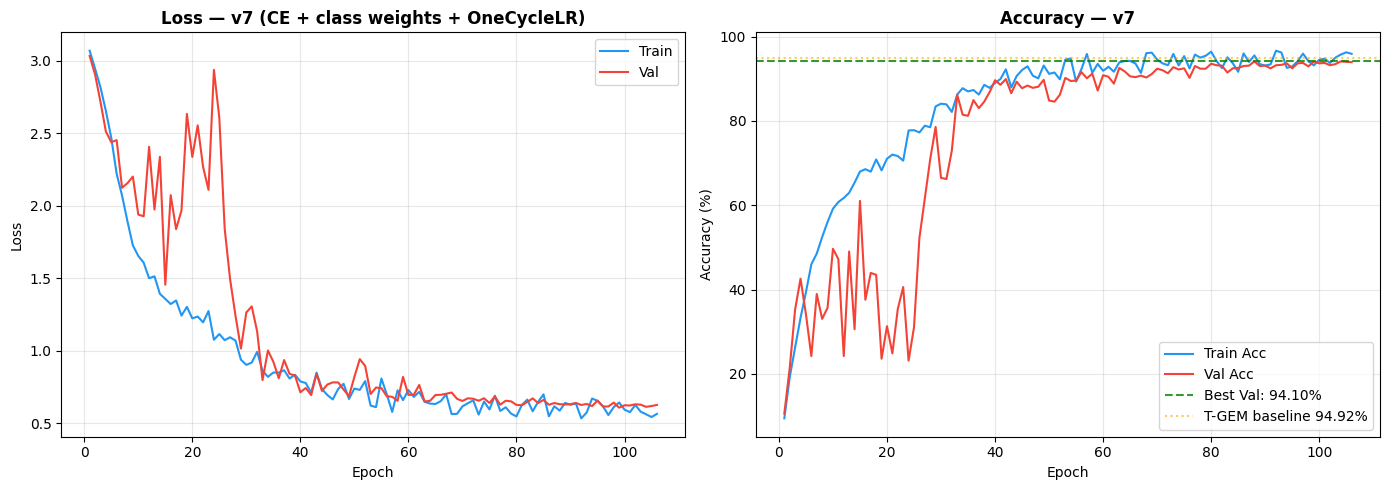

ValueError: not enough values to unpack (expected 5, got 2)

In [10]:
# ── Learning curves ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
er = range(1, len(history['train_loss']) + 1)

axes[0].plot(er, history['train_loss'], label='Train', color='#2196F3', linewidth=1.5)
axes[0].plot(er, history['val_loss'],   label='Val',   color='#F44336', linewidth=1.5)
axes[0].set_title('Loss — v7 (CE + class weights + OneCycleLR)', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(er, history['train_acc'], label='Train Acc', color='#2196F3', linewidth=1.5)
axes[1].plot(er, history['val_acc'],   label='Val Acc',   color='#F44336', linewidth=1.5)
axes[1].axhline(y=best_val_acc, color='green', linestyle='--', alpha=0.8,
                label=f'Best Val: {best_val_acc:.2f}%')
axes[1].axhline(y=94.92, color='orange', linestyle=':', alpha=0.6, label='T-GEM baseline 94.92%')
axes[1].set_title('Accuracy — v7', fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy (%)')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('learning_curves_v7.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Confusion matrix (validation) ─────────────────────────────────────────
model.eval()
preds_cm, labels_cm = [], []
with torch.no_grad():
    for mrna, cnv, mut, meth, labels in val_loader:
        with torch.cuda.amp.autocast(enabled=CONFIG['use_amp']):
            out = model(mrna.to(DEVICE), cnv.to(DEVICE),
                        mut.to(DEVICE), meth.to(DEVICE))
        preds_cm.extend(out.argmax(1).cpu().numpy())
        labels_cm.extend(labels.numpy())

cm = confusion_matrix(labels_cm, preds_cm)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(18, 15))
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_,
            ax=ax, linewidths=0.5, linecolor='gray',
            annot_kws={'size': 7})
ax.set_title(f'Normalised Confusion Matrix — Val Acc {best_val_acc:.2f}%', fontsize=13, fontweight='bold')
ax.set_xlabel('Predicted', fontsize=11); ax.set_ylabel('True', fontsize=11)
ax.tick_params(axis='x', rotation=45, labelsize=8)
ax.tick_params(axis='y', rotation=0,  labelsize=8)
plt.tight_layout()
plt.savefig('confusion_matrix_v7.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Per-class accuracy bar chart ──────────────────────────────────────────
per_class_acc = cm_norm.diagonal()
sorted_idx    = np.argsort(per_class_acc)
fig, ax = plt.subplots(figsize=(10, 12))
colors = ['#e74c3c' if v < 0.85 else '#f39c12' if v < 0.93 else '#2ecc71'
          for v in per_class_acc[sorted_idx]]
ax.barh([le.classes_[i] for i in sorted_idx], per_class_acc[sorted_idx],
        color=colors, edgecolor='black', linewidth=0.4)
ax.axvline(0.94, color='blue', linestyle='--', alpha=0.7, label='94% target')
ax.set_xlabel('Per-class Accuracy'); ax.set_title('Per-class Accuracy (val)', fontweight='bold')
ax.legend(); plt.tight_layout()
plt.savefig('per_class_accuracy_v7.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'\nClasses below 85% accuracy: '
      f'{[le.classes_[i] for i in np.where(per_class_acc < 0.85)[0]]}')


In [ ]:
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
te_str   = f'{te_acc:.2f}%' if test_loader is not None else 'N/A'
te_mf1_str = f'{te_mf1:.4f}' if test_loader is not None else 'N/A'

print('=' * 72)
print('  FINAL RESULTS — OncoBridge-MMCAT v7')
print('=' * 72)
print(f'  Modalities:     mRNA + CNV + Mutation + Methylation (4-way)')
print(f'  Gene counts:    {gene_k}')
print(f'  Classes:        {CONFIG["num_classes"]}')
print(f'  Parameters:     {n_params:,}')
print(f'  Architecture:   embed=384 | enc_layers=6 | cross_attn=4 | 4 modalities')
print()
print(f'  Val Accuracy:   {best_val_acc:.2f}%')
print(f'  Val Weighted F1:{val_wf1:.4f}')
print(f'  Val Macro F1:   {val_mf1:.4f}')
print(f'  Val MCC:        {val_mcc:.4f}')
print(f'  Test Accuracy:  {te_str}')
print(f'  Test Macro F1:  {te_mf1_str}')
print()
print('  Benchmark comparison:')
print('  ───────────────────────────────────────────────────────────────────')
print('  Model                Acc       Classes  Modalities  Notes')
print('  ───────────────────────────────────────────────────────────────────')
print(f'  OncoBridge v7 (ours){best_val_acc:>7.2f}%   {CONFIG["num_classes"]}       4          This run')
print('  OncoBridge v3       91.94%   22       3          Best 3-mod result')
print('  OncoBridge v4       89.24%   31       3          Focal hurt CE')
print('  OncoBridge v5       83.95%   31       3          Overengineered')
print('  T-GEM               94.92%   33       1 (mRNA)   10,340 samples')
print('  Pathformer (F1)     ~0.73    survival 3          KEGG pathways')
print('  ───────────────────────────────────────────────────────────────────')
print()
print('  Key v7 improvements over all prior versions:')
print('  ✅ Mutation NOT scaled (binary 0/1 — StandardScaler was destroying this)')
print('  ✅ Methylation NOT scaled (beta values [0,1] — already bounded)')
print('  ✅ CNV uses MaxAbsScaler (preserves 0 = normal diploid)')
print('  ✅ 4th modality: DNA methylation (epigenetic silencing signal)')
print('  ✅ Gene importance gate init=1.5 (mostly open, learns to close on noise)')
print('  ✅ Auto-k gene selection (principled, not arbitrary number)')
print('  ✅ OneCycleLR retained (proven in v3, CosineRestarts failed in v5)')
print('  ✅ CE + class weights retained (proven in v3, focal failed in v4)')
print('  ✅ Mixup prob=0.5 retained (v3 proven)')
print()
print('  Next step: Drug Response Prediction')
print('  → Use trained encoder weights as Patient Module')
print('  → Add Drug Module (GNN on SMILES from GDSC/CCLE)')
print('  → Concatenate [patient_vec | drug_vec] → IC50 regression')
print('=' * 72)
